
# **Homework: Building PPO from Scratch**
**Course:** Applied Reinforcement Learning Systems  
**Week:** 2  
**Due:** Next Monday at 11:59 PM  
**Points:** 100  

---

### 🧠 Overview

In this assignment, you will implement **Proximal Policy Optimization (PPO)** from scratch using PyTorch and Gymnasium — without relying on external RL libraries such as Stable Baselines3.

Your goals:
- Build the core PPO training algorithm.
- Implement Generalized Advantage Estimation (GAE).
- Train your agent on `CartPole-v1` or `MountainCarContinuous-v0`.
- Plot reward and diagnostic curves.

---


## 1. Environment Setup (10 pts)

In [30]:
# Install dependencies (uncomment if needed)
# !pip install gymnasium torch matplotlib numpy

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Choose device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


## 2. Policy and Value Networks (15 pts)

In [31]:
NEURON_NODE_NUM = 64

class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.simple_network = nn.Sequential(
            nn.Linear(obs_dim, NEURON_NODE_NUM),
            nn.ReLU(),
            nn.Linear(NEURON_NODE_NUM, NEURON_NODE_NUM),
            nn.ReLU(),
            nn.Linear(NEURON_NODE_NUM, act_dim)
        )

    def forward(self, x):
        logits = self.simple_network(x)
        return torch.distributions.Categorical(logits=logits)


class Critic(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.simple_network = nn.Sequential(
            nn.Linear(obs_dim, NEURON_NODE_NUM),
            nn.ReLU(),
            nn.Linear(NEURON_NODE_NUM, NEURON_NODE_NUM),
            nn.ReLU(),
            nn.Linear(NEURON_NODE_NUM, 1)
        )

    def forward(self, x):
        return self.simple_network(x).squeeze(-1)


## 3. Rollout Collection (15 pts)

In [32]:
def collect_rollout(env, actor, critic, batch_size, device=DEVICE):
    obs_dim = env.observation_space.shape[0]

    obs_buf  = np.zeros((batch_size, obs_dim), dtype=np.float32)
    act_buf  = np.zeros(batch_size, dtype=np.int64)
    rew_buf  = np.zeros(batch_size, dtype=np.float32)
    done_buf = np.zeros(batch_size, dtype=np.bool_)
    val_buf  = np.zeros(batch_size, dtype=np.float32)
    logp_buf = np.zeros(batch_size, dtype=np.float32)

    obs, _ = env.reset()
    for t in range(batch_size):
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        dist = actor(obs_tensor)
        value = critic(obs_tensor).detach().cpu().numpy()[0]

        action = dist.sample().detach().cpu().numpy()[0]
        logp = dist.log_prob(torch.tensor(action, device=device)).detach().cpu().numpy().item()

        next_obs, reward, terminated, truncated, info = env.step(int(action))
        done = bool(terminated or truncated)

        obs_buf[t] = obs
        act_buf[t] = int(action)
        rew_buf[t] = float(reward)
        done_buf[t] = done
        val_buf[t] = float(value)
        logp_buf[t] = float(logp)

        if done:
            obs, _ = env.reset()
        else:
            obs = next_obs

    last_obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    last_val = critic(last_obs_tensor).detach().cpu().numpy()[0]

    return {
        'obs': obs_buf,
        'acts': act_buf,
        'rews': rew_buf,
        'dones': done_buf,
        'vals': val_buf,
        'logps': logp_buf,
        'last_val': float(last_val)
    }


## 4. Compute GAE and Returns (15 pts)

In [33]:
def compute_gae(rews, vals, dones, last_val, gamma=0.995, lam=0.95):
    T = len(rews)
    advantages = np.zeros(T, dtype=np.float32)
    lastgaelam = 0.0
    vals_ext = np.append(vals, last_val)

    for t in reversed(range(T)):
        non_terminal = 0.0 if dones[t] else 1.0
        delta = rews[t] + gamma * vals_ext[t + 1] * non_terminal - vals_ext[t]
        lastgaelam = delta + gamma * lam * non_terminal * lastgaelam
        advantages[t] = lastgaelam

    returns = advantages + vals
    return advantages, returns


## 5. PPO Update (25 pts)

In [34]:
def ppo_update(actor, critic, actor_optim, critic_optim, rollout, clip_eps=0.2,
               epochs=10, minibatch_size=64, vf_coef=0.5, ent_coef=0.02, device=DEVICE):

    obs = rollout['obs']
    acts = rollout['acts']
    old_logps = rollout['logps']
    vals = rollout['vals']
    rews = rollout['rews']
    dones = rollout['dones']
    last_val = rollout['last_val']

    advantages, returns = compute_gae(rews, vals, dones, last_val)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    obs_t = torch.tensor(obs, dtype=torch.float32, device=device)
    acts_t = torch.tensor(acts, dtype=torch.long, device=device)
    old_logps_t = torch.tensor(old_logps, dtype=torch.float32, device=device)
    advs_t = torch.tensor(advantages, dtype=torch.float32, device=device)
    returns_t = torch.tensor(returns, dtype=torch.float32, device=device)

    data_size = obs_t.shape[0]
    indices = np.arange(data_size)

    for epoch in range(epochs):
        np.random.shuffle(indices)
        for start in range(0, data_size, minibatch_size):
            mb_idx = indices[start:start + minibatch_size]
            mb_obs = obs_t[mb_idx]
            mb_acts = acts_t[mb_idx]
            mb_old_logps = old_logps_t[mb_idx]
            mb_advs = advs_t[mb_idx]
            mb_returns = returns_t[mb_idx]

            dist = actor(mb_obs)
            new_logps = dist.log_prob(mb_acts)
            entropy = dist.entropy().mean()

            ratio = torch.exp(new_logps - mb_old_logps)
            surr1 = ratio * mb_advs
            surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * mb_advs
            policy_loss = -torch.mean(torch.min(surr1, surr2))

            values_pred = critic(mb_obs).squeeze(-1)
            value_loss = torch.mean((mb_returns - values_pred) ** 2)

            total_loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

            actor_optim.zero_grad()
            critic_optim.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=0.5)
            torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=0.5)
            actor_optim.step()
            critic_optim.step()


## 6. Training Loop (15 pts)

In [35]:
def train_ppo(env_name="CartPole-v1",
              total_iterations=200,
              batch_size=2048,
              epochs=10,
              minibatch_size=64,
              clip_eps=0.2,
              gamma=0.99,
              lam=0.95,
              actor_lr=3e-4,
              critic_lr=1e-3,
              seed=0):

    env = gym.make(env_name)
    env.reset(seed=seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    actor = Actor(obs_dim, act_dim).to(DEVICE)
    critic = Critic(obs_dim).to(DEVICE)

    actor_optim = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_optim = optim.Adam(critic.parameters(), lr=critic_lr)

    rewards_history = []
    last100 = deque(maxlen=100)

    for iteration in range(total_iterations):
        rollout = collect_rollout(env, actor, critic, batch_size, device=DEVICE)

        ep_returns = []
        acc = 0.0
        for r, d in zip(rollout['rews'], rollout['dones']):
            acc += r
            if d:
                ep_returns.append(acc)
                last100.append(acc)
                acc = 0.0
        if acc > 0.0:
            ep_returns.append(acc)

        mean_ret = np.mean(ep_returns) if len(ep_returns) > 0 else 0.0
        rewards_history.append(mean_ret)
        avg_last100 = np.mean(last100) if len(last100) > 0 else 0.0

        ppo_update(actor, critic, actor_optim, critic_optim, rollout,
                   clip_eps=clip_eps, epochs=epochs, minibatch_size=minibatch_size)

        print(f"Iter {iteration+1}/{total_iterations} — MeanReturn={mean_ret:.2f} | AvgLast100={avg_last100:.2f}")

    env.close()
    return rewards_history


## 7. Diagnostics and Plots (10 pts)

Iter 1/5000 — MeanReturn=21.22 | AvgLast100=20.99
Iter 2/5000 — MeanReturn=33.03 | AvgLast100=34.31
Iter 3/5000 — MeanReturn=62.06 | AvgLast100=52.54
Iter 4/5000 — MeanReturn=93.09 | AvgLast100=76.26
Iter 5/5000 — MeanReturn=215.58 | AvgLast100=101.30
Iter 6/5000 — MeanReturn=273.07 | AvgLast100=134.34
Iter 7/5000 — MeanReturn=341.33 | AvgLast100=166.97
Iter 8/5000 — MeanReturn=455.11 | AvgLast100=199.97
Iter 9/5000 — MeanReturn=455.11 | AvgLast100=235.32
Iter 10/5000 — MeanReturn=455.11 | AvgLast100=266.07
Iter 11/5000 — MeanReturn=455.11 | AvgLast100=298.85
Iter 12/5000 — MeanReturn=455.11 | AvgLast100=332.78
Iter 13/5000 — MeanReturn=455.11 | AvgLast100=363.67
Iter 14/5000 — MeanReturn=455.11 | AvgLast100=397.98
Iter 15/5000 — MeanReturn=455.11 | AvgLast100=422.76
Iter 16/5000 — MeanReturn=455.11 | AvgLast100=445.74
Iter 17/5000 — MeanReturn=409.60 | AvgLast100=463.75
Iter 18/5000 — MeanReturn=455.11 | AvgLast100=478.28
Iter 19/5000 — MeanReturn=455.11 | AvgLast100=488.42
Iter 20/50

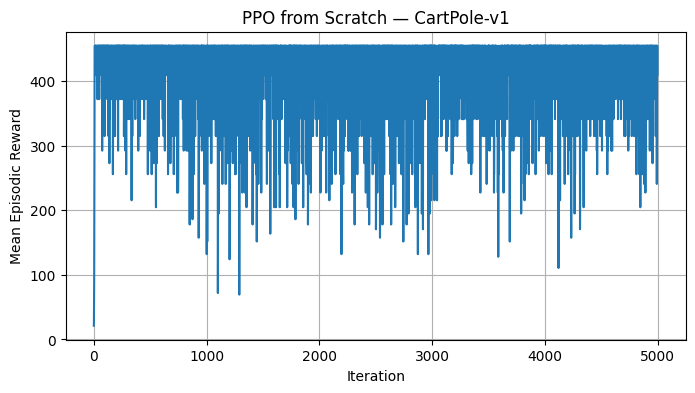

In [36]:
rewards = train_ppo(
    env_name="CartPole-v1",
    total_iterations=5000,
    batch_size=4096,
    epochs=10,
    minibatch_size=64,
    clip_eps=0.2
)

plt.figure(figsize=(8,4))
plt.plot(rewards)
plt.xlabel("Iteration")
plt.ylabel("Mean Episodic Reward")
plt.title("PPO from Scratch — CartPole-v1")
plt.grid(True)
plt.show()



## ✍️ Write-Up (10 pts)

Answer the following in a Markdown cell or PDF:
1. What was the most challenging part to implement?
2. How did the clip range and advantage normalization affect learning?
3. What metrics or plots helped you understand PPO's behavior?

---

### 🧩 Extra Credit (+10 pts)
- Add entropy regularization to the policy loss.
- Try `clip_eps=0.1` and `clip_eps=0.3` and compare results.
- Train on `LunarLander-v3` instead of CartPole (requires Box2D).

---

### 💯 Grading Rubric

| Component | Points |
|------------|--------|
| Environment setup and architecture | 10 |
| Rollout buffer | 15 |
| Advantage (GAE) computation | 15 |
| PPO loss and update | 25 |
| Training loop and results | 15 |
| Plots and interpretation | 10 |
| Write-up clarity | 10 |
| **Total** | **100** |

Good luck — remember, the goal is to *understand* PPO, not just make it work!


## Write-Up

1. What was the most challenging part to implement?

I wouldn't say there was a specific part that was difficult to implement because each section is pretty well documented and easy to research. The hard part for me was understanding how each part connects to next part.

2. How did the clip range and advantage normalization affect learning?

The clip range stabilized the learning and eliminated potential noise in our learning. Normalizing the advantage helps our loss stay smooth and not explode from the potential high variance. 

3. What metrics or plots helped you understand PPO's behavior?

I didn't do much with metrics. The mean episodic reward was enough for me to visualize the learning curve. That tells me how it learns and whether it learned. From the plot I determined that it was learning smoothly and effectively
